In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

FIGS = Path("/home2/lobib/gen_hack/figures")
FIGS.mkdir(exist_ok=True)

PLOT_DATA = Path("/home2/lobib/gen_hack/data2/plot_data")
PLOT_DATA.mkdir(exist_ok=True)

In [17]:
DATA = Path("/home2/lobib/gen_hack/data/main")
OUT = Path("/home2/lobib/gen_hack/data2")

In [18]:
residuals_df = pd.read_parquet(OUT / "residuals.parquet")
residuals_df = residuals_df.dropna(subset=["residual"])
print(f"{len(residuals_df):,} rows after dropping NAs")
residuals_df.head()

9,174,518 rows after dropping NAs


,STAID,date,station_celsius,era5_celsius,residual,tp,wind,ndvi,dist_to_sea_km,altitude,degurba,degurba_label
0,2,2020-01-01,5.4,3.112396,2.287604,3.236035e-07,2.935515,0.259843,85.605731,160,21,Suburban
1,2,2020-01-02,6.3,4.385101,1.914899,1.831601e-06,3.986341,0.259843,85.605731,160,21,Suburban
2,2,2020-01-03,6.8,6.099335,0.700665,1.481518e-04,4.734711,0.259843,85.605731,160,21,Suburban
3,2,2020-01-04,2.7,1.308136,1.391864,8.525351e-06,4.175328,0.259843,85.605731,160,21,Suburban
4,2,2020-01-05,0.9,1.942871,-1.042871,5.183578e-04,2.081413,0.259843,85.605731,160,21,Suburban


In [19]:
def dms_to_decimal(dms_str):
    dms_str = dms_str.strip()
    sign = 1 if dms_str[0] == "+" else -1
    dms_str = dms_str[1:]
    parts = dms_str.split(":")
    return sign * (float(parts[0]) + float(parts[1]) / 60 + float(parts[2]) / 3600)


stations_df = pd.read_csv(
    DATA / "ECA_blend_tx/stations.txt", skiprows=17, skipinitialspace=True
)
stations_df["lat"] = stations_df["LAT"].apply(dms_to_decimal)
stations_df["lon"] = stations_df["LON"].apply(dms_to_decimal)
stations_df = stations_df[["STAID", "lat", "lon"]]

## Mean residual per station (map)

/tmp/ipykernel_2935911/3951192158.py:6: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



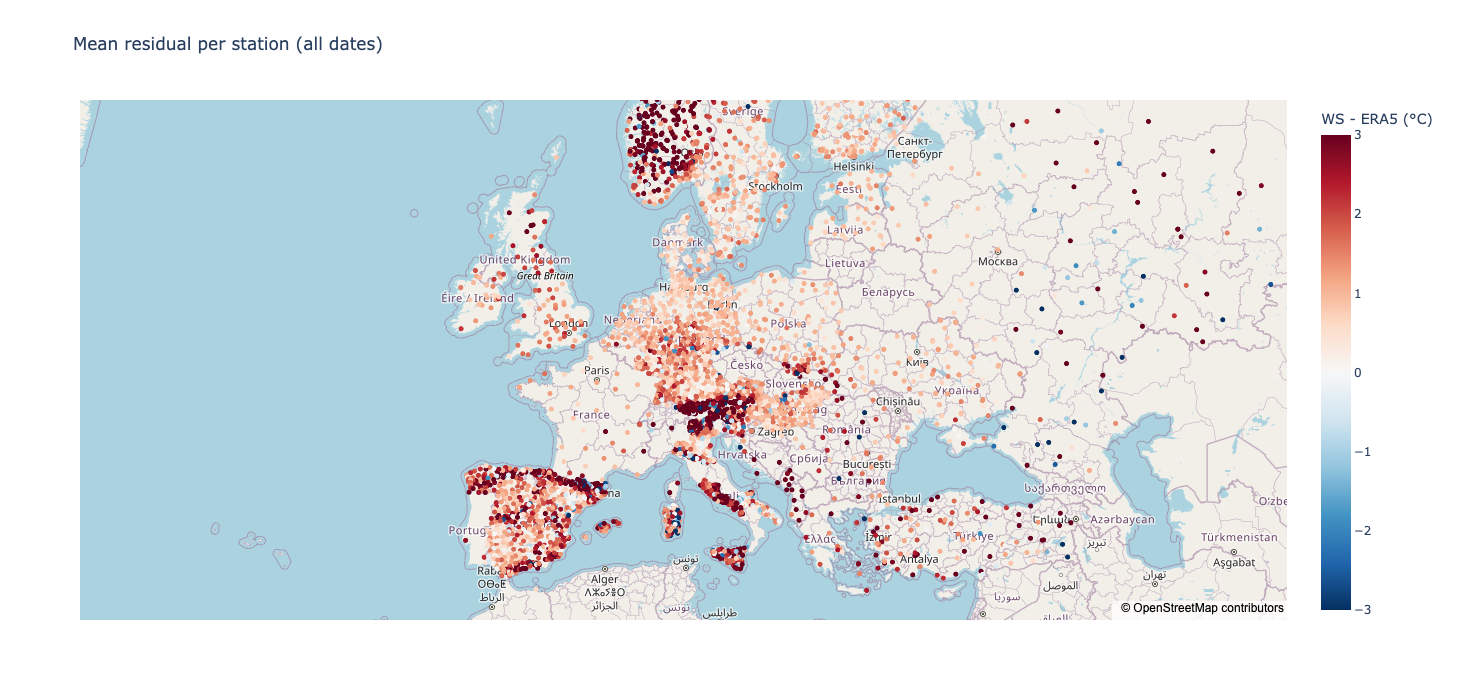

In [20]:
station_mean = (
    residuals_df.groupby("STAID")["residual"].mean().reset_index(name="mean_residual")
)
station_mean = station_mean.merge(stations_df, on="STAID")

fig = px.scatter_mapbox(
    station_mean,
    lat="lat",
    lon="lon",
    color="mean_residual",
    color_continuous_scale="RdBu_r",
    range_color=[-3, 3],
    zoom=3,
    center={"lat": 50, "lon": 10},
    mapbox_style="open-street-map",
    hover_data=["STAID", "mean_residual"],
    title="Mean residual per station (all dates)",
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    height=700,
    width=1000,
    template="plotly_white",
    coloraxis_colorbar_title="WS - ERA5 (°C)",
)
fig.show()
fig.write_html(FIGS / "mean_residual_map.html", include_plotlyjs="cdn")
station_mean.to_parquet(PLOT_DATA / "mean_residual_map.parquet", index=False)

## Partial dependence plots (bootstrap 95% CI)

In [21]:
def cluster_bootstrap_ci(df, bin_col, n_boot=1000, ci=95):
    """Cluster bootstrap at station level: resample STAIDs, compute mean residual per bin."""
    rng = np.random.default_rng(42)
    staids = df["STAID"].unique()
    n_stations = len(staids)

    # Precompute per-station, per-bin mean residual and count
    station_bin = (
        df.groupby(["STAID", bin_col], observed=True)["residual"]
        .agg(["mean", "count"])
        .reset_index()
    )

    bins = df[bin_col].cat.categories
    boot_means = np.zeros((n_boot, len(bins)))

    for b in range(n_boot):
        resampled = rng.choice(staids, size=n_stations, replace=True)
        # Count how many times each station was picked
        unique, counts = np.unique(resampled, return_counts=True)
        weights = pd.Series(counts, index=unique, name="weight")

        merged = station_bin[station_bin["STAID"].isin(unique)].copy()
        merged["weight"] = merged["STAID"].map(weights)
        merged["weighted_sum"] = merged["mean"] * merged["count"] * merged["weight"]
        merged["weighted_n"] = merged["count"] * merged["weight"]

        agg = merged.groupby(bin_col, observed=True)[
            ["weighted_sum", "weighted_n"]
        ].sum()
        boot_means[b] = (agg["weighted_sum"] / agg["weighted_n"]).reindex(bins).values

    lo_pct = (100 - ci) / 2
    hi_pct = 100 - lo_pct
    ci_lo = np.percentile(boot_means, lo_pct, axis=0)
    ci_hi = np.percentile(boot_means, hi_pct, axis=0)
    return ci_lo, ci_hi


def pdp_cluster_bootstrap(df, feature, n_bins=5, n_boot=1000):
    """Bin feature into quantiles, compute mean residual + cluster bootstrap 95% CI."""
    tmp = df.dropna(subset=[feature, "residual"]).copy()
    tmp["bin"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")

    grouped = tmp.groupby("bin", observed=True)["residual"]
    centers = np.array([iv.mid for iv in grouped.mean().index])
    means = grouped.mean().values

    ci_lo, ci_hi = cluster_bootstrap_ci(tmp, "bin", n_boot=n_boot)

    return centers, means, ci_lo, ci_hi

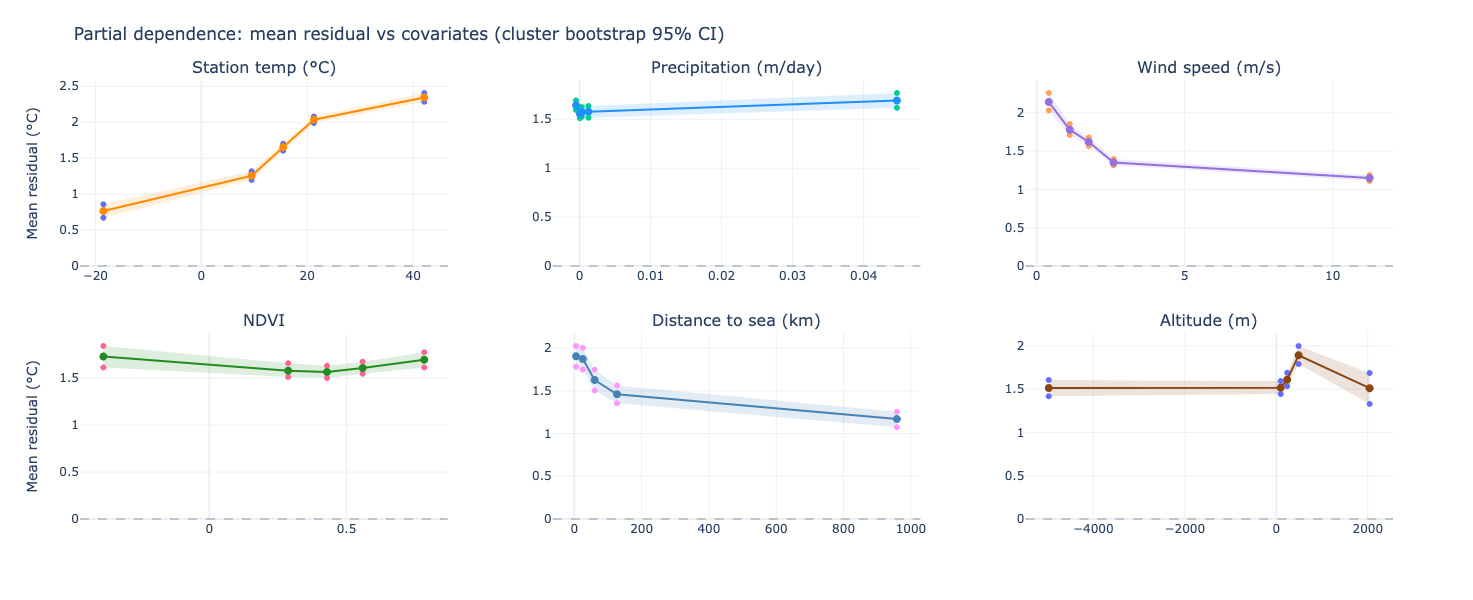

In [22]:
features = {
    "station_celsius": ("Station temp (°C)", "rgb(255,140,0)"),
    "tp": ("Precipitation (m/day)", "rgb(30,144,255)"),
    "wind": ("Wind speed (m/s)", "rgb(147,112,219)"),
    "ndvi": ("NDVI", "rgb(34,139,34)"),
    "dist_to_sea_km": ("Distance to sea (km)", "rgb(70,130,180)"),
    "altitude": ("Altitude (m)", "rgb(139,69,19)"),
}

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[v[0] for v in features.values()],
    horizontal_spacing=0.08,
    vertical_spacing=0.15,
)

pdp_records = []
for i, (col, (label, rgb)) in enumerate(features.items()):
    row, c = divmod(i, 3)
    row += 1
    c += 1
    rgba = rgb.replace("rgb(", "rgba(").replace(")", ",0.15)")

    centers, mean, ci_lo, ci_hi = pdp_cluster_bootstrap(residuals_df, col)

    for j in range(len(centers)):
        pdp_records.append({"feature": col, "label": label, "rgb": rgb, "center": centers[j], "mean": mean[j], "ci_lo": ci_lo[j], "ci_hi": ci_hi[j]})

    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row,
        col=c,
    )

    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=rgb),
            line=dict(color=rgb, width=2),
            name=label,
            showlegend=False,
            hovertemplate=f"{label}: %{{x:.2f}}<br>Mean: %{{y:.3f}} °C<extra></extra>",
        ),
        row=row,
        col=c,
    )

    fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4, row=row, col=c)

fig.update_layout(
    height=600,
    width=1200,
    template="plotly_white",
    title="Partial dependence: mean residual vs covariates (cluster bootstrap 95% CI)",
    margin=dict(t=80),
)
fig.update_yaxes(title_text="Mean residual (°C)", col=1)
fig.show()
fig.write_html(FIGS / "pdp.html", include_plotlyjs="cdn")
pd.DataFrame(pdp_records).to_parquet(PLOT_DATA / "pdp.parquet", index=False)

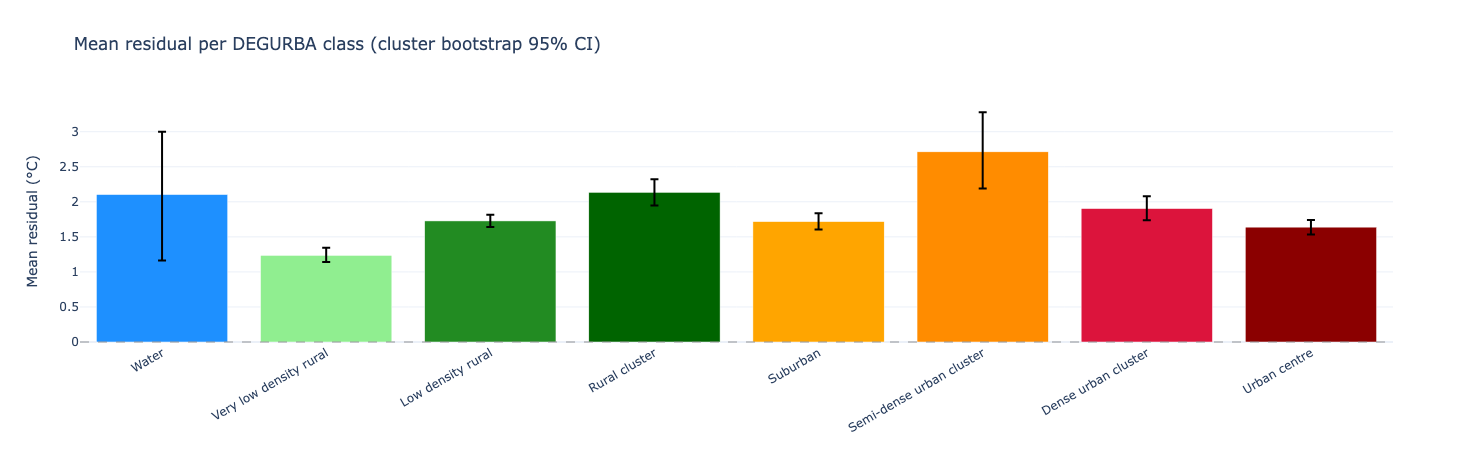

In [23]:
degurba_order = [
    "Water",
    "Very low density rural",
    "Low density rural",
    "Rural cluster",
    "Suburban",
    "Semi-dense urban cluster",
    "Dense urban cluster",
    "Urban centre",
]
degurba_colors = [
    "rgb(30,144,255)",
    "rgb(144,238,144)",
    "rgb(34,139,34)",
    "rgb(0,100,0)",
    "rgb(255,165,0)",
    "rgb(255,140,0)",
    "rgb(220,20,60)",
    "rgb(139,0,0)",
]

tmp = residuals_df.dropna(subset=["degurba_label", "residual"]).copy()
tmp["degurba_label"] = pd.Categorical(
    tmp["degurba_label"], categories=degurba_order, ordered=True
)
tmp = tmp.dropna(subset=["degurba_label"])

rng = np.random.default_rng(42)
staids = tmp["STAID"].unique()
n_stations = len(staids)
station_agg = (
    tmp.groupby(["STAID", "degurba_label"], observed=True)["residual"]
    .agg(["mean", "count"])
    .reset_index()
)
cats = [c for c in degurba_order if c in tmp["degurba_label"].values]

n_boot = 1000
boot_means = np.zeros((n_boot, len(cats)))
for b in range(n_boot):
    resampled = rng.choice(staids, size=n_stations, replace=True)
    unique, counts = np.unique(resampled, return_counts=True)
    weights = pd.Series(counts, index=unique, name="weight")
    merged = station_agg[station_agg["STAID"].isin(unique)].copy()
    merged["weight"] = merged["STAID"].map(weights)
    merged["ws"] = merged["mean"] * merged["count"] * merged["weight"]
    merged["wn"] = merged["count"] * merged["weight"]
    agg = merged.groupby("degurba_label", observed=True)[["ws", "wn"]].sum()
    boot_means[b] = (agg["ws"] / agg["wn"]).reindex(cats).values

deg_means = (
    tmp.groupby("degurba_label", observed=True)["residual"].mean().reindex(cats).values
)
ci_lo = np.percentile(boot_means, 2.5, axis=0)
ci_hi = np.percentile(boot_means, 97.5, axis=0)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=cats,
        y=deg_means,
        marker_color=degurba_colors[: len(cats)],
        error_y=dict(
            type="data",
            symmetric=False,
            array=ci_hi - deg_means,
            arrayminus=deg_means - ci_lo,
            color="black",
            thickness=2,
            width=4,
        ),
        showlegend=False,
        hovertemplate="%{x}<br>Mean: %{y:.3f} °C<extra></extra>",
    ),
)
fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=450,
    width=800,
    template="plotly_white",
    title="Mean residual per DEGURBA class (cluster bootstrap 95% CI)",
    yaxis_title="Mean residual (°C)",
    xaxis_tickangle=-30,
)
fig.show()
fig.write_html(FIGS / "degurba_pdp.html", include_plotlyjs="cdn")
pd.DataFrame({"degurba_label": cats, "mean": deg_means, "ci_lo": ci_lo, "ci_hi": ci_hi, "color": degurba_colors[:len(cats)]}).to_parquet(PLOT_DATA / "degurba_pdp.parquet", index=False)

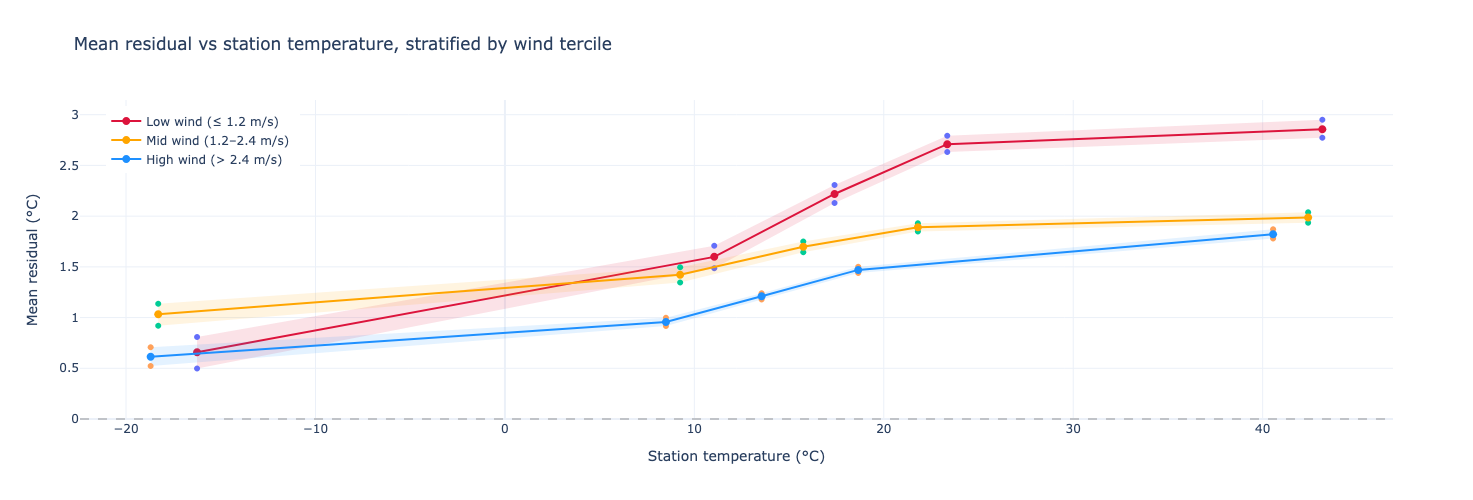

In [24]:
wind_terciles = residuals_df["wind"].quantile([1 / 3, 2 / 3]).values
low_wind = residuals_df[residuals_df["wind"] <= wind_terciles[0]]
mid_wind = residuals_df[
    (residuals_df["wind"] > wind_terciles[0])
    & (residuals_df["wind"] <= wind_terciles[1])
]
high_wind = residuals_df[residuals_df["wind"] > wind_terciles[1]]

centers_lo, mean_lo, ci_lo_lo, ci_hi_lo = pdp_cluster_bootstrap(
    low_wind, "station_celsius"
)
centers_mid, mean_mid, ci_lo_mid, ci_hi_mid = pdp_cluster_bootstrap(
    mid_wind, "station_celsius"
)
centers_hi, mean_hi, ci_lo_hi, ci_hi_hi = pdp_cluster_bootstrap(
    high_wind, "station_celsius"
)

strat_records = []
for centers, mean, ci_lo, ci_hi, label in [
    (centers_lo, mean_lo, ci_lo_lo, ci_hi_lo, f"Low wind (≤ {wind_terciles[0]:.1f} m/s)"),
    (centers_mid, mean_mid, ci_lo_mid, ci_hi_mid, f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)"),
    (centers_hi, mean_hi, ci_lo_hi, ci_hi_hi, f"High wind (> {wind_terciles[1]:.1f} m/s)"),
]:
    for j in range(len(centers)):
        strat_records.append({"group": label, "center": centers[j], "mean": mean[j], "ci_lo": ci_lo[j], "ci_hi": ci_hi[j]})

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (
        centers_lo,
        mean_lo,
        ci_lo_lo,
        ci_hi_lo,
        "rgb(220,20,60)",
        f"Low wind (≤ {wind_terciles[0]:.1f} m/s)",
    ),
    (
        centers_mid,
        mean_mid,
        ci_lo_mid,
        ci_hi_mid,
        "rgb(255,165,0)",
        f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)",
    ),
    (
        centers_hi,
        mean_hi,
        ci_lo_hi,
        ci_hi_hi,
        "rgb(30,144,255)",
        f"High wind (> {wind_terciles[1]:.1f} m/s)",
    ),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs station temperature, stratified by wind tercile",
    xaxis_title="Station temperature (°C)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()
fig.write_html(FIGS / "temp_pdp_cond_wind.html", include_plotlyjs="cdn")
pd.DataFrame(strat_records).to_parquet(PLOT_DATA / "temp_pdp_cond_wind.parquet", index=False)

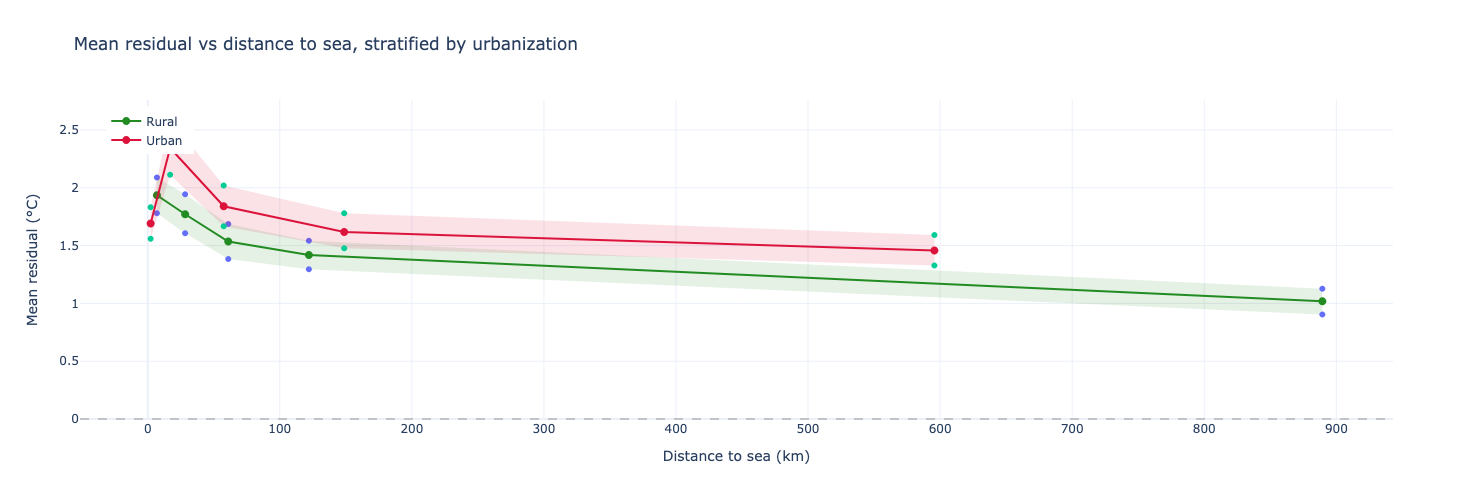

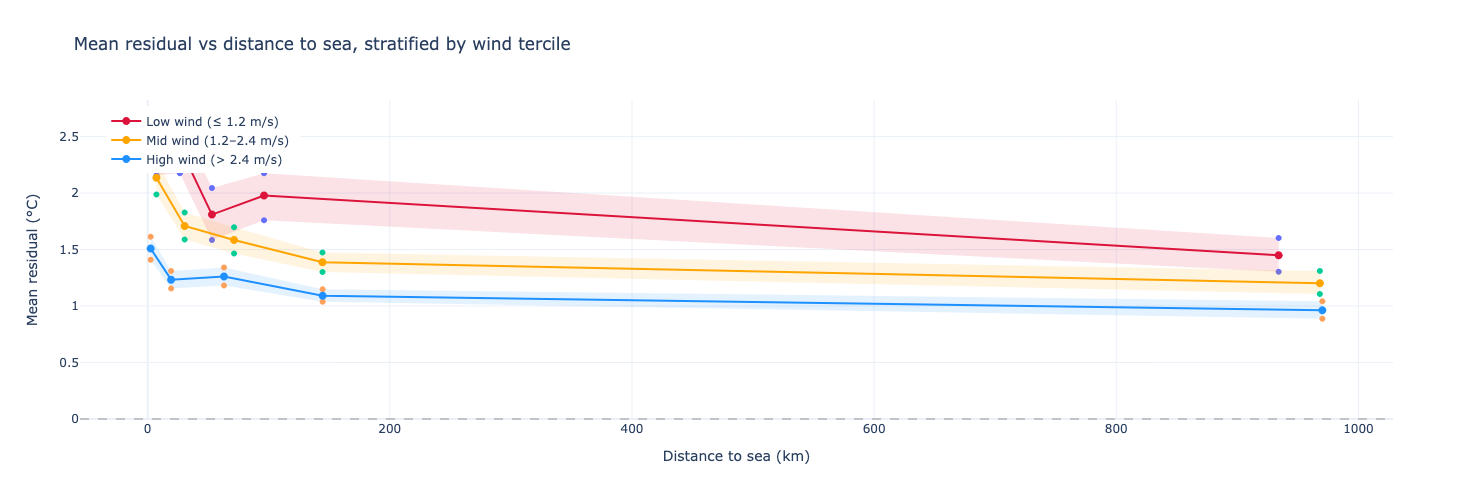

In [17]:
# 1. Distance to sea stratified by DEGURBA (rural vs urban)
rural_labels = ["Very low density rural", "Low density rural", "Rural cluster"]
urban_labels = [
    "Suburban",
    "Semi-dense urban cluster",
    "Dense urban cluster",
    "Urban centre",
]

rural = residuals_df[residuals_df["degurba_label"].isin(rural_labels)]
urban = residuals_df[residuals_df["degurba_label"].isin(urban_labels)]

centers_r, mean_r, ci_lo_r, ci_hi_r = pdp_cluster_bootstrap(rural, "dist_to_sea_km")
centers_u, mean_u, ci_lo_u, ci_hi_u = pdp_cluster_bootstrap(urban, "dist_to_sea_km")

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (centers_r, mean_r, ci_lo_r, ci_hi_r, "rgb(34,139,34)", "Rural"),
    (centers_u, mean_u, ci_lo_u, ci_hi_u, "rgb(220,20,60)", "Urban"),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs distance to sea, stratified by urbanization",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()

# 2. Distance to sea stratified by wind tercile
wind_terciles = residuals_df["wind"].quantile([1 / 3, 2 / 3]).values
low_wind = residuals_df[residuals_df["wind"] <= wind_terciles[0]]
mid_wind = residuals_df[
    (residuals_df["wind"] > wind_terciles[0])
    & (residuals_df["wind"] <= wind_terciles[1])
]
high_wind = residuals_df[residuals_df["wind"] > wind_terciles[1]]

centers_lo, mean_lo, ci_lo_lo, ci_hi_lo = pdp_cluster_bootstrap(
    low_wind, "dist_to_sea_km"
)
centers_mid, mean_mid, ci_lo_mid, ci_hi_mid = pdp_cluster_bootstrap(
    mid_wind, "dist_to_sea_km"
)
centers_hi, mean_hi, ci_lo_hi, ci_hi_hi = pdp_cluster_bootstrap(
    high_wind, "dist_to_sea_km"
)

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (
        centers_lo,
        mean_lo,
        ci_lo_lo,
        ci_hi_lo,
        "rgb(220,20,60)",
        f"Low wind (≤ {wind_terciles[0]:.1f} m/s)",
    ),
    (
        centers_mid,
        mean_mid,
        ci_lo_mid,
        ci_hi_mid,
        "rgb(255,165,0)",
        f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)",
    ),
    (
        centers_hi,
        mean_hi,
        ci_lo_hi,
        ci_hi_hi,
        "rgb(30,144,255)",
        f"High wind (> {wind_terciles[1]:.1f} m/s)",
    ),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs distance to sea, stratified by wind tercile",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()

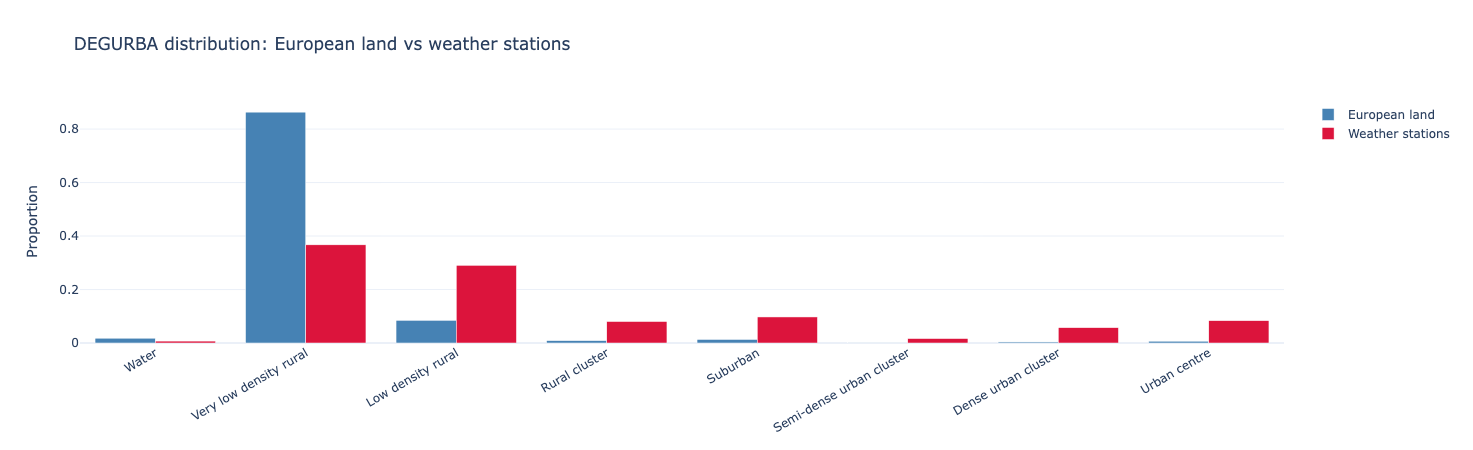

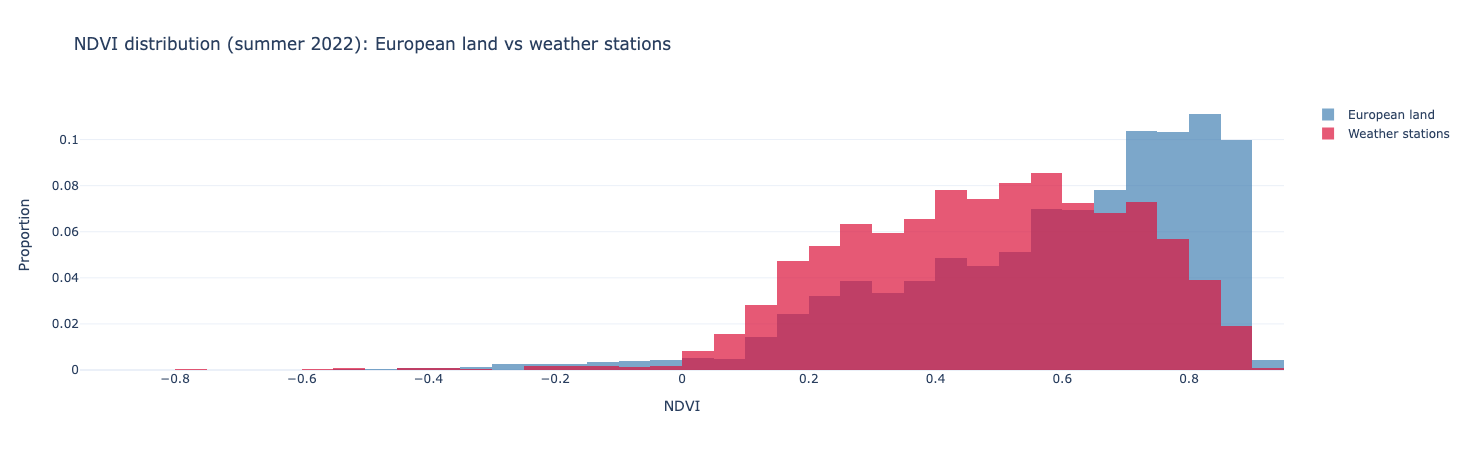

In [ ]:
# Sample DEGURBA and NDVI across all European land pixels, compare to station distributions
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform_bounds

# Load Europe boundary for masking
gadm = gpd.read_file(DATA / "gadm_410_europe.gpkg")
europe = gadm.dissolve()

# --- DEGURBA: station vs all European land ---
degurba_path = (
    OUT
    / "GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0/GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0.tif"
)

with rasterio.open(degurba_path) as src:
    europe_reproj = europe.to_crs(src.crs)
    masked, _ = rio_mask(src, europe_reproj.geometry, crop=True, nodata=src.nodata)
    degurba_all = masked[0]
    degurba_all = degurba_all[degurba_all != src.nodata]
    degurba_all = degurba_all[degurba_all > 0]  # drop zeros if any

DEGURBA_LABELS = {
    10: "Water",
    11: "Very low density rural",
    12: "Low density rural",
    13: "Rural cluster",
    21: "Suburban",
    22: "Semi-dense urban cluster",
    23: "Dense urban cluster",
    30: "Urban centre",
}
degurba_order = list(DEGURBA_LABELS.values())

# Reference distribution (all European land pixels)
ref_degurba = (
    pd.Series(degurba_all)
    .map(DEGURBA_LABELS)
    .value_counts(normalize=True)
    .reindex(degurba_order)
    .fillna(0)
)

# Station distribution
sta_degurba = (
    residuals_df.drop_duplicates("STAID")["degurba_label"]
    .value_counts(normalize=True)
    .reindex(degurba_order)
    .fillna(0)
)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=ref_degurba.values,
        name="European land",
        marker_color="rgb(70,130,180)",
    )
)
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=sta_degurba.values,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
    )
)
fig.update_layout(
    barmode="group",
    height=450,
    width=900,
    template="plotly_white",
    title="DEGURBA distribution: European land vs weather stations",
    yaxis_title="Proportion",
    xaxis_tickangle=-30,
)
fig.show()

# --- NDVI: station vs all European land (use one quarter as representative) ---
ndvi_dir = DATA / "sentinel2_ndvi/"
# Pick a summer quarter for representative vegetation
ndvi_path = ndvi_dir / "ndvi_2022-06-01_2022-09-01.tif"

with rasterio.open(ndvi_path) as src:
    europe_reproj = europe.to_crs(src.crs)
    masked, _ = rio_mask(src, europe_reproj.geometry, crop=True, nodata=src.nodata)
    ndvi_all = masked[0].astype(float)
    ndvi_all = ndvi_all[ndvi_all != src.nodata]
    ndvi_all = ndvi_all / 254 * 2 - 1  # same rescaling as in pipeline

# Subsample reference (millions of pixels)
rng = np.random.default_rng(42)
ndvi_ref_sample = rng.choice(ndvi_all, size=100_000, replace=False)

# Station NDVI for same quarter
sta_ndvi = (
    residuals_df.loc[
        (residuals_df["date"] >= "2022-06-01") & (residuals_df["date"] < "2022-09-01"),
        "ndvi",
    ]
    .dropna()
    .values
)

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=ndvi_ref_sample,
        nbinsx=50,
        name="European land",
        marker_color="rgb(70,130,180)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.add_trace(
    go.Histogram(
        x=sta_ndvi,
        nbinsx=50,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.update_layout(
    barmode="overlay",
    height=450,
    width=800,
    template="plotly_white",
    title="NDVI distribution (summer 2022): European land vs weather stations",
    xaxis_title="NDVI",
    yaxis_title="Proportion",
)
fig.show()

# --- Distance to sea: station vs uniform European land sample ---
from shapely.geometry import Point

# Sample random points on European land
europe_3035 = europe.to_crs("EPSG:3035")
bounds = europe_3035.total_bounds  # minx, miny, maxx, maxy
coastline = europe_3035.boundary.iloc[0]

rng = np.random.default_rng(42)
n_samples = 20_000
random_points = []
while len(random_points) < n_samples:
    xs = rng.uniform(bounds[0], bounds[2], size=n_samples * 2)
    ys = rng.uniform(bounds[1], bounds[3], size=n_samples * 2)
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs="EPSG:3035")
    inside = pts[pts.within(europe_3035.geometry.iloc[0])]
    random_points.extend(inside.tolist())
random_points = random_points[:n_samples]

ref_dist_sea = gpd.GeoSeries(random_points, crs="EPSG:3035").distance(coastline) / 1000

# Station distances
sta_dist_sea = residuals_df.drop_duplicates("STAID")["dist_to_sea_km"].dropna()

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=ref_dist_sea,
        nbinsx=50,
        name="European land (uniform)",
        marker_color="rgb(70,130,180)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.add_trace(
    go.Histogram(
        x=sta_dist_sea,
        nbinsx=50,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.update_layout(
    barmode="overlay",
    height=450,
    width=800,
    template="plotly_white",
    title="Distance to sea distribution: uniform European land vs weather stations",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Proportion",
)
fig.show()